### kNN

In [1]:
import pandas as pd

In [2]:
# 데이터 불러오기
train = pd.read_csv('../Data/basketball_train.csv')
test = pd.read_csv('../Data/basketball_test.csv')

In [3]:
train.head()

,Player,Pos,3P,TRB,BLK
0,Pau Gasol,C,0.9,7.8,1.1
1,Nicolas Batum,SG,1.8,6.2,0.4
2,Allen Crabbe,SG,1.7,2.9,0.3
3,Manu Ginobili,SG,1.3,2.3,0.2
4,Danny Green,SG,1.7,3.3,0.8


In [5]:
test.head()

,Player,Pos,3P,TRB,BLK
0,Avery Bradley,SG,2.0,6.1,0.2
1,Zach LaVine,SG,2.6,3.4,0.2
2,Troy Daniels,SG,2.1,1.5,0.1
3,Will Barton,SG,1.5,4.3,0.5
4,Willie Cauley-Stein,C,0.0,4.5,0.6


In [6]:
# 전체 갯수 확인
print(train.shape)
print(test.shape)

(80, 5)
(20, 5)


In [7]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80 entries, 0 to 79
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Player  80 non-null     object 
 1   Pos     80 non-null     object 
 2   3P      80 non-null     float64
 3   TRB     80 non-null     float64
 4   BLK     80 non-null     float64
dtypes: float64(3), object(2)
memory usage: 3.3+ KB


In [8]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Player  20 non-null     object 
 1   Pos     20 non-null     object 
 2   3P      20 non-null     float64
 3   TRB     20 non-null     float64
 4   BLK     20 non-null     float64
dtypes: float64(3), object(2)
memory usage: 932.0+ bytes


#### 최적의 k 찾기와 교차 검증(Cross Validation)
 교차 검증 : 실제 test 로 시험보기 전에 train 에서 또 train / valid 로 나눠서 사전 시험 보는 거.   # 데이터 갯수가 작을 때 혹은 머신 러닝에선 무조건 해야함.

In [9]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score    # 이거 하면 알아서 cross validation 함

In [15]:
# 최적의 k를 찾기 위해 교차 검증을 수행할 k 의 범위를 3부터 학습 데이터의 절반까지 지정  (보통 절반 이후 정확도가 확 떨어짐)
max_x_range = train.shape[0] // 2   # 짝수일 땐 '/' 로 가능하지만 홀수일 땐 실수가 나오므로 '//' 로 몫만 구해주면 됨.

In [40]:
# 최적의 k를 찾기 위한 범위 확인
k_list = [i for i in range(3, max_x_range, 2)]    # range 는 정수 형태만 취급하므로 위에서 정수 형태가 나오게 해야 함.


In [17]:
train_data = train[['3P', 'BLK', 'TRB']]
train_target = train['Pos']

In [58]:
# 교차 검증(10 fold)을 각 k를 대상으로 수행해 검증 결과를 저장
# 10 등분해서 1 부분을 test 로 나머지를 train 으로 하는 작업을 여러 번 반복
cross_validation_scores = []
for k in k_list:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(
        knn,
        train_data,
        train_target,
        cv=10,       # cross validation : 9개는 학습용, 1개는 검증용으로 쓰는 걸 10번.
        scoring='accuracy'    # 점수 : 정확도  로 할 거임
    )
    print (k, ":", scores)
    cross_validation_scores.append(scores.mean())

    # (?) 데이터 총 갯수가 적을 때 교차 검증을 하는데, 얘를 교차 검증하지 않고 유리한 k 만 찾았을 때, 교차 검증하지 않은 것과 교차 검증을 하고 평균을 낸 것의
    # k 의 우열이 뒤바뀔 정도로 차이가 나는지, 왜 그런지?
    
    # (답) 충분히 그럴 수 있습니다.
     # 교차 검증을 하지 않으면 한 번의 데이터 분할 결과에 크게 영향을 받습니다. 
     # 운 좋게 쉬운 검증 데이터가 선택되면 특정 k가 좋아 보일 수 있고, 반대로 어려운 검증 데이터가 선택되면 성능이 낮게 나올 수도 있습니다.
     # 반면 교차 검증은 여러 번 다른 방식으로 학습/검증을 반복한 뒤 평균을 내므로, 데이터 분할에 따른 우연한 영향을 줄여 더 안정적으로 k를 선택할 수 있습니다. 
     # 특히 데이터가 적을수록 이런 차이가 더 크게 나타날 가능성이 있습니다.


3 : [0.875 0.875 0.875 0.875 0.875 0.875 0.75  1.    1.    0.75 ]
5 : [0.875 0.75  0.875 0.875 1.    1.    0.75  1.    1.    0.875]
7 : [0.875 0.625 0.875 0.875 1.    0.875 0.75  1.    1.    0.875]
9 : [0.875 0.625 0.875 0.875 1.    1.    0.75  1.    1.    0.875]
11 : [0.875 0.625 0.875 0.875 1.    1.    0.75  1.    1.    0.875]
13 : [0.875 0.625 0.875 0.875 1.    1.    0.75  1.    1.    0.875]
15 : [0.875 0.625 0.875 0.875 1.    1.    0.75  1.    1.    0.875]
17 : [0.875 0.625 0.875 0.875 1.    1.    0.75  1.    1.    0.875]
19 : [0.875 0.625 0.875 0.875 1.    1.    0.75  1.    1.    0.875]
21 : [0.875 0.625 0.875 0.875 1.    1.    0.75  1.    1.    0.875]
23 : [0.875 0.625 0.875 0.875 1.    1.    0.75  1.    1.    0.875]
25 : [0.875 0.625 0.875 0.875 1.    1.    0.75  1.    1.    0.875]
27 : [0.875 0.625 0.875 0.875 1.    1.    0.75  1.    1.    0.875]
29 : [0.875 0.625 0.875 0.875 1.    0.875 0.75  1.    1.    0.875]
31 : [0.875 0.625 0.875 0.875 1.    0.875 0.75  1.    1.    0.875]

In [21]:
print(cross_validation_scores)

[np.float64(0.875), np.float64(0.9), np.float64(0.875), np.float64(0.8875), np.float64(0.8875), np.float64(0.8875), np.float64(0.8875), np.float64(0.8875), np.float64(0.8875), np.float64(0.8875), np.float64(0.8875), np.float64(0.8875), np.float64(0.8875), np.float64(0.875), np.float64(0.875), np.float64(0.8625), np.float64(0.85), np.float64(0.8375), np.float64(0.8375)]


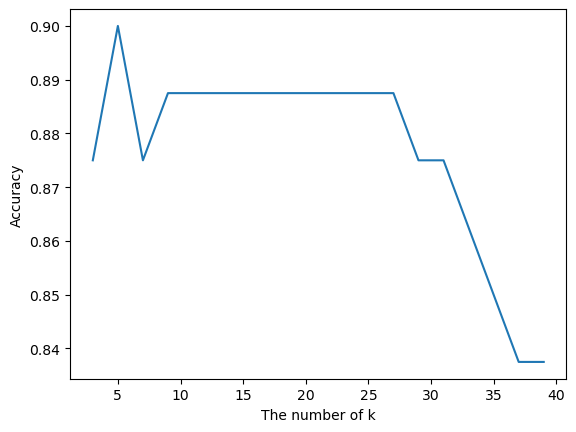

In [22]:
import matplotlib.pyplot as plt
# k의 정확도 시각화
plt.plot(
    k_list,
    cross_validation_scores,
)

plt.xlabel('The number of k')
plt.ylabel('Accuracy')

plt.show()

In [26]:
# 가장 예측율이 높은 k를 선정
k_list[cross_validation_scores.index(max(cross_validation_scores))]

5

----
#### 2개의 특징으로 예측하기(3점슛, 블로킹)

In [27]:
# Model
knn = KNeighborsClassifier(n_neighbors=5)

In [28]:
# Feature
train_data = train[['3P', 'BLK']]

In [29]:
# Target
train_target = train['Pos']

In [30]:
# 학습시키기
knn.fit(train_data, train_target)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [31]:
test_data = test[['3P', 'BLK']]
test_target = test['Pos']

In [35]:
# 평가하기  - 이 차이가 5% 내로 나야 좋은 거.
print(knn.score(train_data, train_target))
print(knn.score(test_data, test_target))

0.9625
0.95


----
#### 3개의 특징으로 예측하기 (3점슛, 블로킹, 리바운드)

In [36]:
train_data = train[['3P', 'BLK', 'TRB']]
train_target = train['Pos']

In [37]:
test_data = test[['3P', 'BLK', 'TRB']]
test_target = test['Pos']

In [53]:
knn.fit(train_data, train_target)

,n_neighbors,39
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [39]:
print(knn.score(train_data, train_target))
print(knn.score(test_data, test_target))

0.925
0.9


----
#### 학습한 AI Model 사용해보기
어떤 선수의 점수가
 - 3P : 3.4
 - BLK : 0.5
 - TRB : 3.7

In [51]:
# 점수 입력
data = {
    '3P' : [3.4],
    'BLK' : [0.5],
    'TRB' : [3.7]
}
df= pd.DataFrame(data)
df

,3P,BLK,TRB
0,3.4,0.5,3.7


In [54]:
# 예측
knn.predict(df)

array(['SG'], dtype=object)

아래는 내가 한 거임

In [45]:
# 데이터를 넣을 때 기존 파일의 데이터 형식과 똑같이 맞춰줘야 함.
knn.predict([[3.4, 0.5, 3.7]])

c:\Users\tjoeun\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


array(['SG'], dtype=object)

In [47]:
train_data.describe()

,3P,BLK,TRB
count,80.000000,80.000000,80.000000
mean,1.075000,0.711250,5.053750
std,0.922092,0.611906,3.060402
min,0.000000,0.100000,1.300000
25%,0.000000,0.275000,2.800000
50%,1.200000,0.600000,3.900000
75%,1.800000,1.000000,6.650000
max,3.400000,3.000000,13.800000


### AI 저장하기

In [55]:
import joblib

In [57]:
joblib.dump(knn, '../Data/knn_basketball.h5')

['../Data/knn_basketball.h5']